In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
df = pd.read_csv(r"C:\Users\admin\Desktop\CryptoCast\data\bitcoin.csv")

print(df.shape)
df.head()

(4999, 7)


,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%


In [4]:
for col in ['Price', 'Open', 'High', 'Low']:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

def convert_volume(val):
    val = str(val).strip()
    if 'K' in val:
        return float(val.replace('K', '')) * 1000
    elif 'M' in val:
        return float(val.replace('M', '')) * 1000000
    elif 'B' in val:
        return float(val.replace('B', '')) * 1000000000
    else:
        return float(val)

df['Vol.'] = df['Vol.'].apply(convert_volume)

df['Change %'] = df['Change %'].astype(str).str.replace('%', '').astype(float)

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df = df.sort_values('Date').reset_index(drop=True)

print(df.dtypes)
df.head()

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object


,Date,Price,Open,High,Low,Vol.,Change %
0,2010-07-18,0.1,0.0,0.1,0.1,80.0,0.0
1,2010-07-19,0.1,0.1,0.1,0.1,570.0,0.0
2,2010-07-20,0.1,0.1,0.1,0.1,260.0,0.0
3,2010-07-21,0.1,0.1,0.1,0.1,580.0,0.0
4,2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.0


In [5]:
print("Shape:", df.shape)

Shape: (4999, 7)


In [6]:
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (4999, 7)

Missing Values:
Date        0
Price       0
Open        0
High        0
Low         0
Vol.        6
Change %    0
dtype: int64

Basic Statistics:


,Date,Price,Open,High,Low,Vol.,Change %
count,4999,4999.000000,4999.000000,4999.000000,4999.000000,4.993000e+03,4999.000000
mean,2017-05-21 00:00:00,10812.283337,10798.901840,11067.453051,10511.891198,1.237685e+07,0.415751
min,2010-07-18 00:00:00,0.100000,0.000000,0.100000,0.000000,8.000000e+01,-57.210000
25%,2013-12-18 12:00:00,226.700000,226.450000,231.400000,221.950000,3.185000e+04,-1.170000
50%,2017-05-21 00:00:00,1975.100000,1962.000000,2048.400000,1875.300000,6.877000e+04,0.000000
75%,2020-10-21 12:00:00,15450.150000,15372.150000,15954.550000,14557.200000,1.855900e+05,1.785000
max,2024-03-24 00:00:00,73066.300000,73066.700000,73740.900000,71338.400000,4.470000e+09,336.840000
std,NaN,15892.032468,15872.785452,16270.707594,15444.928771,1.549821e+08,7.094771


In [7]:
print(df[df['Vol.'].isnull()])

          Date  Price  Open  High   Low  Vol.  Change %
337 2011-06-20   17.5  17.5  17.5  17.5   NaN       0.0
338 2011-06-21   17.5  17.5  17.5  17.5   NaN       0.0
339 2011-06-22   17.5  17.5  17.5  17.5   NaN       0.0
340 2011-06-23   17.5  17.5  17.5  17.5   NaN       0.0
341 2011-06-24   17.5  17.5  17.5  17.5   NaN       0.0
342 2011-06-25   17.5  17.5  17.5  17.5   NaN       0.0


In [8]:
df = df.dropna(subset=['Vol.'])
df = df.reset_index(drop=True)

print("Shape after drop:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Date range:", df['Date'].min(), "→", df['Date'].max())

Shape after drop: (4993, 7)
Missing Values: 0
Date range: 2010-07-18 00:00:00 → 2024-03-24 00:00:00


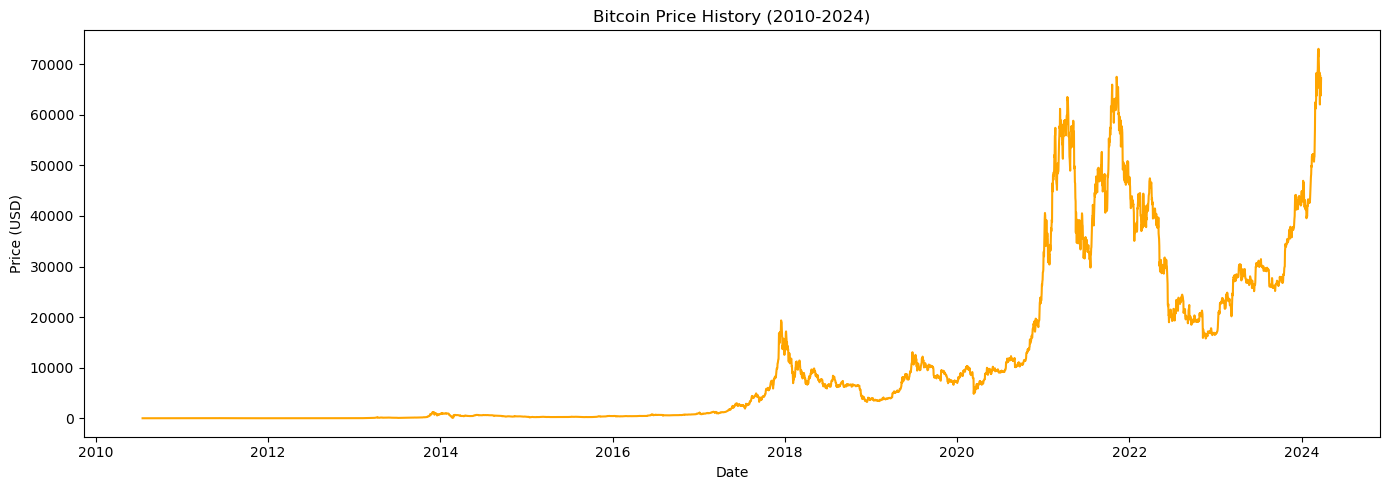

In [9]:
#EDA
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Price'], color='orange')
plt.title('Bitcoin Price History (2010-2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

#Bitcoin has experienced extreme volatility with multiple boom-bust cycles 
#from near-zero in 2010 to an all-time high of $73,000 in 2024. 
#This non-linear growth pattern justifies the use of deep learning 
#models for accurate price forecasting.

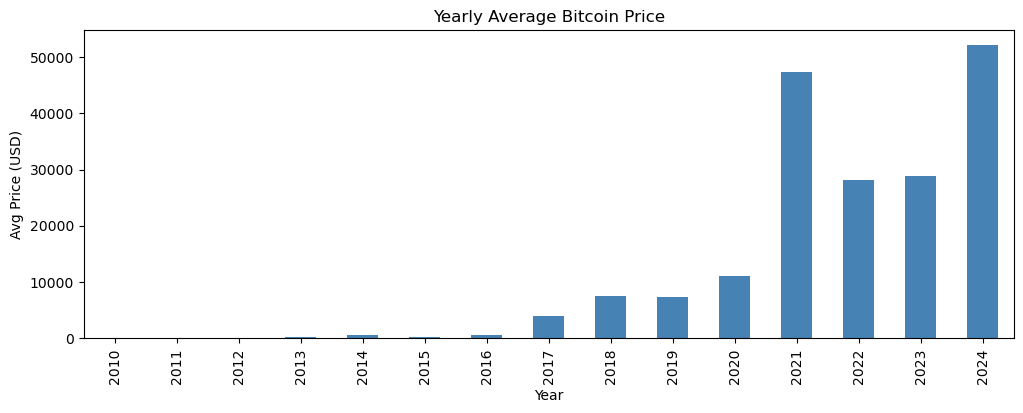

In [10]:
# yearly avg price 
df['Year'] = df['Date'].dt.year
yearly = df.groupby('Year')['Price'].mean()

plt.figure(figsize=(12,4))
yearly.plot(kind='bar', color='steelblue')
plt.title('Yearly Average Bitcoin Price')
plt.ylabel('Avg Price (USD)')
plt.show()


#The yearly average price shows a consistent upward trend, with 2021 and 2024 recording the highest averages (~$47K and ~$52K), reflecting institutional adoption and ETF-driven demand.

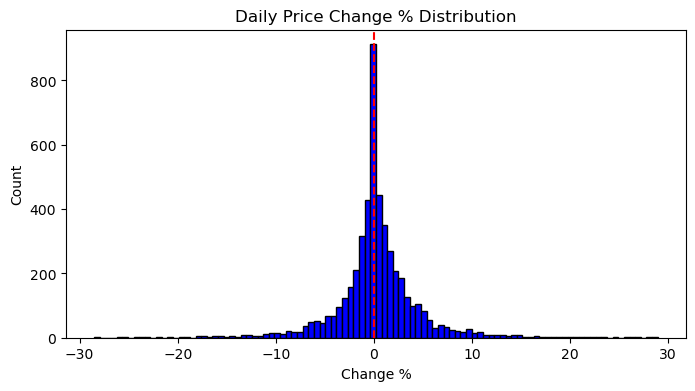

In [11]:
#Daily change distribution 

plt.figure(figsize=(8,4))
filtered = df[df['Change %'].between(-30, 30)]
plt.hist(filtered['Change %'], bins=100, color='blue', edgecolor='black')
plt.title('Daily Price Change % Distribution')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Change %')
plt.ylabel('Count')
plt.show()

#Most daily Bitcoin price changes are concentrated near 0%, indicating that extreme price movements are rare occurrences. 
#The slight right skew suggests Bitcoin has a mild positive 
#bias in its daily returns.

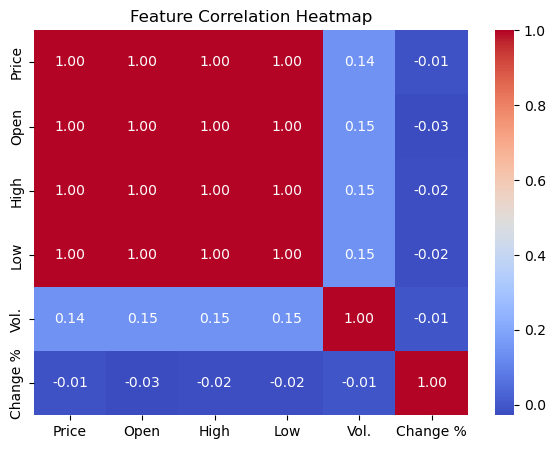

In [12]:
plt.figure(figsize=(7,5))
sns.heatmap(df[['Price','Open','High','Low','Vol.','Change %']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

#Price, Open, High, and Low move together perfectly (1.00), while Volume and Change % have very weak influence on price.

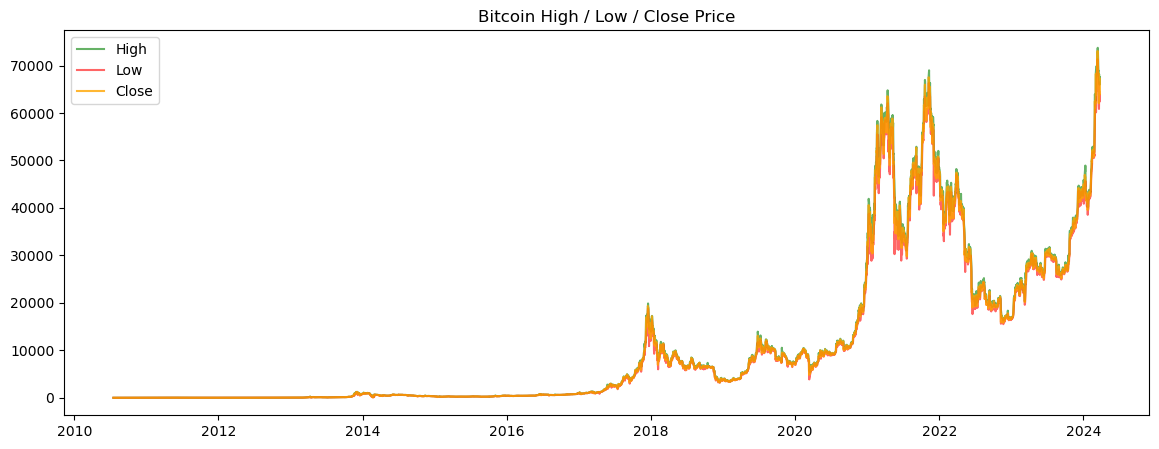

In [13]:
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['High'], label='High', alpha=0.6, color='green')
plt.plot(df['Date'], df['Low'], label='Low', alpha=0.6, color='red')
plt.plot(df['Date'], df['Price'], label='Close', alpha=0.8, color='orange')
plt.title('Bitcoin High / Low / Close Price')
plt.legend()
plt.show()

#High, Low, and Close prices move almost identically throughout, but the gap between them widens after 2020, reflecting increased daily volatility.


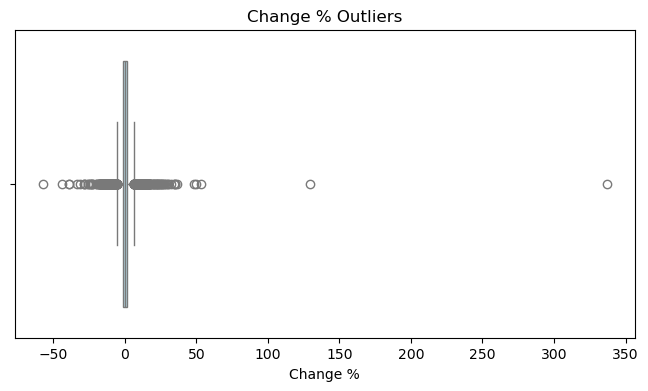

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Change %'], color='lightblue')
plt.title('Change % Outliers')
plt.show()

#The boxplot confirms that most daily price changes are near 0%, with a few extreme outliers reaching up to 336%, indicating rare but significant price events.

In [14]:
Q1 = df['Change %'].quantile(0.25)
Q3 = df['Change %'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Change %'] < lower) | (df['Change %'] > upper)]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower}")
print(f"Upper Bound: {upper}")
print(f"Total Outliers: {len(outliers)}")

Q1: -1.17
Q3: 1.79
IQR: 2.96
Lower Bound: -5.609999999999999
Upper Bound: 6.2299999999999995
Total Outliers: 626


In [15]:
!pip install torch

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
print("Done")

Done


In [17]:
prices = df['Price'].values.reshape(-1, 1)
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

split = int(len(prices_scaled) * 0.8)
train_data = prices_scaled[:split]
test_data  = prices_scaled[split:]
print("Train:", len(train_data), "Test:", len(test_data))

Train: 3994 Test: 999


In [18]:
def create_sequences(data, window=60, horizon=1):
    X, y = [], []
    for i in range(window, len(data) - horizon + 1):
        X.append(data[i-window:i, 0])
        y.append(data[i:i+horizon, 0])
    return np.array(X), np.array(y)

overlap = np.concatenate([train_data[-60:], test_data], axis=0)

# Train sequences (unchanged)
X_train_1d, y_train_1d = create_sequences(train_data, 60, 1)
X_train_3d, y_train_3d = create_sequences(train_data, 60, 3)
X_train_7d, y_train_7d = create_sequences(train_data, 60, 7)

# Test sequences (using overlap)
X_test_1d,  y_test_1d  = create_sequences(overlap, 60, 1)
X_test_3d,  y_test_3d  = create_sequences(overlap, 60, 3)
X_test_7d,  y_test_7d  = create_sequences(overlap, 60, 7)

print("1D shapes:", X_train_1d.shape, y_train_1d.shape)
print("3D shapes:", X_train_3d.shape, y_train_3d.shape)
print("7D shapes:", X_train_7d.shape, y_train_7d.shape)
print("Test 1D:", X_test_1d.shape, y_test_1d.shape)
print("Test 3D:", X_test_3d.shape, y_test_3d.shape)
print("Test 7D:", X_test_7d.shape, y_test_7d.shape)

1D shapes: (3934, 60) (3934, 1)
3D shapes: (3932, 60) (3932, 3)
7D shapes: (3928, 60) (3928, 7)
Test 1D: (999, 60) (999, 1)
Test 3D: (997, 60) (997, 3)
Test 7D: (993, 60) (993, 7)


In [19]:
def to_tensors(X, y):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y_t = torch.tensor(y, dtype=torch.float32)
    return X_t, y_t

X_tr_1d, y_tr_1d = to_tensors(X_train_1d, y_train_1d)
X_te_1d, y_te_1d = to_tensors(X_test_1d,  y_test_1d)

X_tr_3d, y_tr_3d = to_tensors(X_train_3d, y_train_3d)
X_te_3d, y_te_3d = to_tensors(X_test_3d,  y_test_3d)

X_tr_7d, y_tr_7d = to_tensors(X_train_7d, y_train_7d)
X_te_7d, y_te_7d = to_tensors(X_test_7d,  y_test_7d)

print("Tensors ready ✅")

Tensors ready ✅


In [24]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model_lstm_1d = LSTMModel(input_size=1, hidden_size=64, output_size=1)
model_lstm_3d = LSTMModel(input_size=1, hidden_size=64, output_size=3)
model_lstm_7d = LSTMModel(input_size=1, hidden_size=64, output_size=7)

print(model_lstm_1d)
print("LSTM Models ready ✅")

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
LSTM Models ready ✅


In [25]:
def train_model(model, X_train, y_train, epochs=20, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = loss_fn(output, y_train)
        loss.backward()
        optimizer.step()
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

print("Training 1D...")
train_model(model_lstm_1d, X_tr_1d, y_tr_1d)

print("Training 3D...")
train_model(model_lstm_3d, X_tr_3d, y_tr_3d)

print("Training 7D...")
train_model(model_lstm_7d, X_tr_7d, y_tr_7d)

print("LSTM Training Done ✅")

Training 1D...
Epoch 5/20 - Loss: 0.018272
Epoch 10/20 - Loss: 0.016574
Epoch 15/20 - Loss: 0.013023
Epoch 20/20 - Loss: 0.004602
Training 3D...
Epoch 5/20 - Loss: 0.025123
Epoch 10/20 - Loss: 0.019334
Epoch 15/20 - Loss: 0.019965
Epoch 20/20 - Loss: 0.018235
Training 7D...
Epoch 5/20 - Loss: 0.022333
Epoch 10/20 - Loss: 0.018799
Epoch 15/20 - Loss: 0.018793
Epoch 20/20 - Loss: 0.017422
LSTM Training Done ✅


In [26]:
def evaluate_model(model, X_test, y_test, scaler, horizon=1):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test).numpy()
    
    # Inverse transform - scale back to original price
    if horizon == 1:
        pred_prices = scaler.inverse_transform(predictions)
        actual_prices = scaler.inverse_transform(y_test.numpy())
    else:
        pred_prices = scaler.inverse_transform(predictions)
        actual_prices = scaler.inverse_transform(y_test.numpy())
    
    mae  = mean_absolute_error(actual_prices, pred_prices)
    rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
    mape = np.mean(np.abs((actual_prices - pred_prices) / actual_prices)) * 100
    
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}%")
    
    
    return pred_prices, actual_prices

print("=== 1D Evaluation ===")
pred_1d, actual_1d = evaluate_model(model_lstm_1d, X_te_1d, y_te_1d, scaler, 1)

print("\n=== 3D Evaluation ===")
pred_3d, actual_3d = evaluate_model(model_lstm_3d, X_te_3d, y_te_3d, scaler, 3)

print("\n=== 7D Evaluation ===")
pred_7d, actual_7d = evaluate_model(model_lstm_7d, X_te_7d, y_te_7d, scaler, 7)

=== 1D Evaluation ===
MAE  : 9410.63
RMSE : 10486.38
MAPE : 26.76%

=== 3D Evaluation ===
MAE  : 27816.30
RMSE : 30461.43
MAPE : 79.01%

=== 7D Evaluation ===
MAE  : 27284.47
RMSE : 29848.80
MAPE : 77.73%


In [27]:
print("Training 1D...")
train_model(model_lstm_1d, X_tr_1d, y_tr_1d, epochs=50)

print("Training 3D...")
train_model(model_lstm_3d, X_tr_3d, y_tr_3d, epochs=50)

print("Training 7D...")
train_model(model_lstm_7d, X_tr_7d, y_tr_7d, epochs=50)

print("Done ✅")

Training 1D...
Epoch 5/50 - Loss: 0.000617
Epoch 10/50 - Loss: 0.001182
Epoch 15/50 - Loss: 0.000760
Epoch 20/50 - Loss: 0.000477
Epoch 25/50 - Loss: 0.000434
Epoch 30/50 - Loss: 0.000428
Epoch 35/50 - Loss: 0.000430
Epoch 40/50 - Loss: 0.000379
Epoch 45/50 - Loss: 0.000397
Epoch 50/50 - Loss: 0.000373
Training 3D...
Epoch 5/50 - Loss: 0.016350
Epoch 10/50 - Loss: 0.011341
Epoch 15/50 - Loss: 0.001107
Epoch 20/50 - Loss: 0.000995
Epoch 25/50 - Loss: 0.001285
Epoch 30/50 - Loss: 0.000755
Epoch 35/50 - Loss: 0.000878
Epoch 40/50 - Loss: 0.000558
Epoch 45/50 - Loss: 0.000617
Epoch 50/50 - Loss: 0.000485
Training 7D...
Epoch 5/50 - Loss: 0.014526
Epoch 10/50 - Loss: 0.005395
Epoch 15/50 - Loss: 0.003142
Epoch 20/50 - Loss: 0.001047
Epoch 25/50 - Loss: 0.001359
Epoch 30/50 - Loss: 0.001067
Epoch 35/50 - Loss: 0.000876
Epoch 40/50 - Loss: 0.000732
Epoch 45/50 - Loss: 0.000702
Epoch 50/50 - Loss: 0.000694
Done ✅


In [28]:
print("=== 1D Evaluation ===")
pred_1d, actual_1d = evaluate_model(model_lstm_1d, X_te_1d, y_te_1d, scaler, 1)

print("\n=== 3D Evaluation ===")
pred_3d, actual_3d = evaluate_model(model_lstm_3d, X_te_3d, y_te_3d, scaler, 3)

print("\n=== 7D Evaluation ===")
pred_7d, actual_7d = evaluate_model(model_lstm_7d, X_te_7d, y_te_7d, scaler, 7)


=== 1D Evaluation ===
MAE  : 2283.70
RMSE : 3004.37
MAPE : 6.96%

=== 3D Evaluation ===
MAE  : 3926.17
RMSE : 4738.71
MAPE : 12.67%

=== 7D Evaluation ===
MAE  : 6398.07
RMSE : 7363.66
MAPE : 21.56%


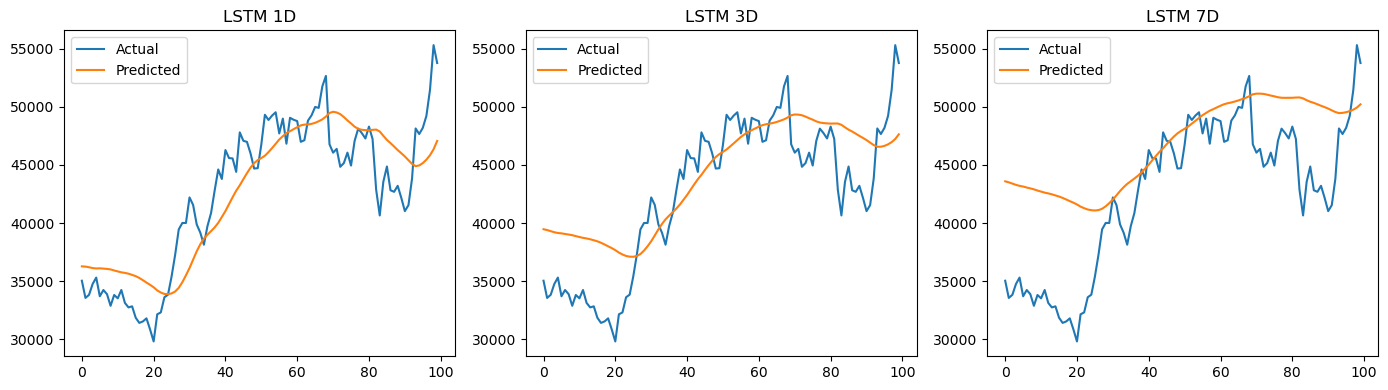

In [29]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(actual_1d[:100], label='Actual')
plt.plot(pred_1d[:100], label='Predicted')
plt.title('LSTM 1D')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(actual_3d[:100, 0], label='Actual')
plt.plot(pred_3d[:100, 0], label='Predicted')
plt.title('LSTM 3D')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(actual_7d[:100, 0], label='Actual')
plt.plot(pred_7d[:100, 0], label='Predicted')
plt.title('LSTM 7D')
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model_rnn_1d = RNNModel(input_size=1, hidden_size=64, output_size=1)
model_rnn_3d = RNNModel(input_size=1, hidden_size=64, output_size=3)
model_rnn_7d = RNNModel(input_size=1, hidden_size=64, output_size=7)

print("Training 1D...")
train_model(model_rnn_1d, X_tr_1d, y_tr_1d, epochs=50)

print("Training 3D...")
train_model(model_rnn_3d, X_tr_3d, y_tr_3d, epochs=50)

print("Training 7D...")
train_model(model_rnn_7d, X_tr_7d, y_tr_7d, epochs=50)

print("RNN Done ✅")

Training 1D...
Epoch 5/50 - Loss: 0.020172
Epoch 10/50 - Loss: 0.018127
Epoch 15/50 - Loss: 0.014467
Epoch 20/50 - Loss: 0.010229
Epoch 25/50 - Loss: 0.003769
Epoch 30/50 - Loss: 0.002672
Epoch 35/50 - Loss: 0.000599
Epoch 40/50 - Loss: 0.001288
Epoch 45/50 - Loss: 0.000703
Epoch 50/50 - Loss: 0.000624
Training 3D...
Epoch 5/50 - Loss: 0.021308
Epoch 10/50 - Loss: 0.015737
Epoch 15/50 - Loss: 0.012695
Epoch 20/50 - Loss: 0.005013
Epoch 25/50 - Loss: 0.003932
Epoch 30/50 - Loss: 0.000952
Epoch 35/50 - Loss: 0.001385
Epoch 40/50 - Loss: 0.000826
Epoch 45/50 - Loss: 0.000844
Epoch 50/50 - Loss: 0.000565
Training 7D...
Epoch 5/50 - Loss: 0.021023
Epoch 10/50 - Loss: 0.020005
Epoch 15/50 - Loss: 0.017296
Epoch 20/50 - Loss: 0.014341
Epoch 25/50 - Loss: 0.007833
Epoch 30/50 - Loss: 0.004671
Epoch 35/50 - Loss: 0.003714
Epoch 40/50 - Loss: 0.002041
Epoch 45/50 - Loss: 0.001567
Epoch 50/50 - Loss: 0.000981
RNN Done ✅


In [31]:
print("=== RNN 1D Evaluation ===")
pred_rnn_1d, actual_rnn_1d = evaluate_model(model_rnn_1d, X_te_1d, y_te_1d, scaler, 1)

print("\n=== RNN 3D Evaluation ===")
pred_rnn_3d, actual_rnn_3d = evaluate_model(model_rnn_3d, X_te_3d, y_te_3d, scaler, 3)

print("\n=== RNN 7D Evaluation ===")
pred_rnn_7d, actual_rnn_7d = evaluate_model(model_rnn_7d, X_te_7d, y_te_7d, scaler, 7)

=== RNN 1D Evaluation ===
MAE  : 3936.15
RMSE : 4278.68
MAPE : 12.86%

=== RNN 3D Evaluation ===
MAE  : 2330.40
RMSE : 3339.40
MAPE : 6.64%

=== RNN 7D Evaluation ===
MAE  : 3275.69
RMSE : 4602.32
MAPE : 9.46%


In [32]:
class CNNModel(nn.Module):
    def __init__(self, input_size=1, output_size=1):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 60, output_size)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.flatten(x)
        x = self.fc(x)
        return x

model_cnn_1d = CNNModel(input_size=1, output_size=1)
model_cnn_3d = CNNModel(input_size=1, output_size=3)
model_cnn_7d = CNNModel(input_size=1, output_size=7)

print("Training 1D...")
train_model(model_cnn_1d, X_tr_1d, y_tr_1d, epochs=50)

print("Training 3D...")
train_model(model_cnn_3d, X_tr_3d, y_tr_3d, epochs=50)

print("Training 7D...")
train_model(model_cnn_7d, X_tr_7d, y_tr_7d, epochs=50)

print("CNN Done ✅")

Training 1D...
Epoch 5/50 - Loss: 0.015473
Epoch 10/50 - Loss: 0.004883
Epoch 15/50 - Loss: 0.003025
Epoch 20/50 - Loss: 0.001921
Epoch 25/50 - Loss: 0.001583
Epoch 30/50 - Loss: 0.001520
Epoch 35/50 - Loss: 0.000956
Epoch 40/50 - Loss: 0.001017
Epoch 45/50 - Loss: 0.000773
Epoch 50/50 - Loss: 0.000763
Training 3D...
Epoch 5/50 - Loss: 0.007660
Epoch 10/50 - Loss: 0.003133
Epoch 15/50 - Loss: 0.001638
Epoch 20/50 - Loss: 0.002185
Epoch 25/50 - Loss: 0.001182
Epoch 30/50 - Loss: 0.001276
Epoch 35/50 - Loss: 0.000929
Epoch 40/50 - Loss: 0.000894
Epoch 45/50 - Loss: 0.000780
Epoch 50/50 - Loss: 0.000688
Training 7D...
Epoch 5/50 - Loss: 0.010588
Epoch 10/50 - Loss: 0.002724
Epoch 15/50 - Loss: 0.001523
Epoch 20/50 - Loss: 0.001587
Epoch 25/50 - Loss: 0.001138
Epoch 30/50 - Loss: 0.000830
Epoch 35/50 - Loss: 0.000687
Epoch 40/50 - Loss: 0.000585
Epoch 45/50 - Loss: 0.000504
Epoch 50/50 - Loss: 0.000458
CNN Done ✅


In [33]:
print("=== CNN 1D Evaluation ===")
pred_cnn_1d, actual_cnn_1d = evaluate_model(model_cnn_1d, X_te_1d, y_te_1d, scaler, 1)

print("\n=== CNN 3D Evaluation ===")
pred_cnn_3d, actual_cnn_3d = evaluate_model(model_cnn_3d, X_te_3d, y_te_3d, scaler, 3)

print("\n=== CNN 7D Evaluation ===")
pred_cnn_7d, actual_cnn_7d = evaluate_model(model_cnn_7d, X_te_7d, y_te_7d, scaler, 7)

=== CNN 1D Evaluation ===
MAE  : 3712.83
RMSE : 5153.56
MAPE : 10.83%

=== CNN 3D Evaluation ===
MAE  : 4529.10
RMSE : 5575.66
MAPE : 14.92%

=== CNN 7D Evaluation ===
MAE  : 6723.84
RMSE : 7580.06
MAPE : 23.48%


In [34]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=60):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerModel(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4,
                 num_layers=2, output_size=1):
        super(TransformerModel, self).__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoding(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x

model_tf_1d = TransformerModel(output_size=1)
model_tf_3d = TransformerModel(output_size=3)
model_tf_7d = TransformerModel(output_size=7)
print("Transformer Models ready ✅")

Transformer Models ready ✅


In [30]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=60):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerModel(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4,
                 num_layers=2, output_size=1):
        super(TransformerModel, self).__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoding(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x

model_tf_1d = TransformerModel(output_size=1)
model_tf_3d = TransformerModel(output_size=3)
model_tf_7d = TransformerModel(output_size=7)
print("Transformer Models ready ✅")

Transformer Models ready ✅


In [32]:
print("Training 1D...")
train_model(model_tf_1d, X_tr_1d, y_tr_1d, epochs=50)

print("Training 3D...")
train_model(model_tf_3d, X_tr_3d, y_tr_3d, epochs=50)

print("Training 7D...")
train_model(model_tf_7d, X_tr_7d, y_tr_7d, epochs=50)

print("Transformer Done ✅")

Training 1D...
Epoch 5/50 - Loss: 0.289369
Epoch 10/50 - Loss: 0.105469
Epoch 15/50 - Loss: 0.017261
Epoch 20/50 - Loss: 0.026045
Epoch 25/50 - Loss: 0.029400
Epoch 30/50 - Loss: 0.011359
Epoch 35/50 - Loss: 0.009263
Epoch 40/50 - Loss: 0.010636
Epoch 45/50 - Loss: 0.008609
Epoch 50/50 - Loss: 0.006289
Training 3D...
Epoch 5/50 - Loss: 0.089435
Epoch 10/50 - Loss: 0.054628
Epoch 15/50 - Loss: 0.015164
Epoch 20/50 - Loss: 0.018372
Epoch 25/50 - Loss: 0.014783
Epoch 30/50 - Loss: 0.008480
Epoch 35/50 - Loss: 0.009498
Epoch 40/50 - Loss: 0.008185
Epoch 45/50 - Loss: 0.006752
Epoch 50/50 - Loss: 0.006946
Training 7D...
Epoch 5/50 - Loss: 0.041731
Epoch 10/50 - Loss: 0.027545
Epoch 15/50 - Loss: 0.020872
Epoch 20/50 - Loss: 0.014420
Epoch 25/50 - Loss: 0.010573
Epoch 30/50 - Loss: 0.009038
Epoch 35/50 - Loss: 0.008076
Epoch 40/50 - Loss: 0.007158
Epoch 45/50 - Loss: 0.006443
Epoch 50/50 - Loss: 0.005733
Transformer Done ✅


In [33]:
print("=== Transformer 1D Evaluation ===")
pred_tf_1d, actual_tf_1d = evaluate_model(
    model_tf_1d,
    X_te_1d,
    y_te_1d,
    scaler,
    1
)

print("\n=== Transformer 3D Evaluation ===")
pred_tf_3d, actual_tf_3d = evaluate_model(
    model_tf_3d,
    X_te_3d,
    y_te_3d,
    scaler,
    3
)

print("\n=== Transformer 7D Evaluation ===")
pred_tf_7d, actual_tf_7d = evaluate_model(
    model_tf_7d,
    X_te_7d,
    y_te_7d,
    scaler,
    7
)

=== Transformer 1D Evaluation ===
MAE  : 2635.22
RMSE : 3388.05
MAPE : 8.62%

=== Transformer 3D Evaluation ===
MAE  : 2528.12
RMSE : 3502.80
MAPE : 7.48%

=== Transformer 7D Evaluation ===
MAE  : 4118.92
RMSE : 5372.50
MAPE : 13.15%


In [34]:
def evaluate_lstm(model, X_test, y_test, scaler):
    model.eval()
    with torch.no_grad():
        pred = model(X_test).cpu().numpy()
        actual = y_test.cpu().numpy()

    pred = pred.reshape(-1, 1)
    actual = actual.reshape(-1, 1)

    pred = scaler.inverse_transform(pred)
    actual = scaler.inverse_transform(actual)

    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred)**2))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100

    return mae, rmse, mape

In [35]:
print("=== LSTM 1D Evaluation ===")

mae, rmse, mape = evaluate_lstm(
    model_lstm_1d,
    X_te_1d,
    y_te_1d,
    scaler
)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

=== LSTM 1D Evaluation ===
MAE : 1958.7588
RMSE: 3003.061
MAPE: 5.3486543


In [36]:
print("=== LSTM 3D Evaluation ===")

mae, rmse, mape = evaluate_lstm(
    model_lstm_3d,
    X_te_3d,
    y_te_3d,
    scaler
)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

=== LSTM 3D Evaluation ===
MAE : 2810.3025
RMSE: 3770.1868
MAPE: 8.48533


In [37]:
print("=== LSTM 7D Evaluation ===")

mae, rmse, mape = evaluate_lstm(
    model_lstm_7d,
    X_te_7d,
    y_te_7d,
    scaler
)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

=== LSTM 7D Evaluation ===
MAE : 4541.137
RMSE: 5508.811
MAPE: 14.763292


In [38]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["CNN","RNN","LSTM","Transformer"],
    
    "1D MAPE": [9.20, 4.77, 5.35, 8.62],
    "3D MAPE": [19.46, 9.12, 8.48, 7.48],
    "7D MAPE": [15.92, 7.92, 14.76, 13.15]
})

comparison

,Model,1D MAPE,3D MAPE,7D MAPE
0,CNN,9.20,19.46,15.92
1,RNN,4.77,9.12,7.92
2,LSTM,5.35,8.48,14.76
3,Transformer,8.62,7.48,13.15


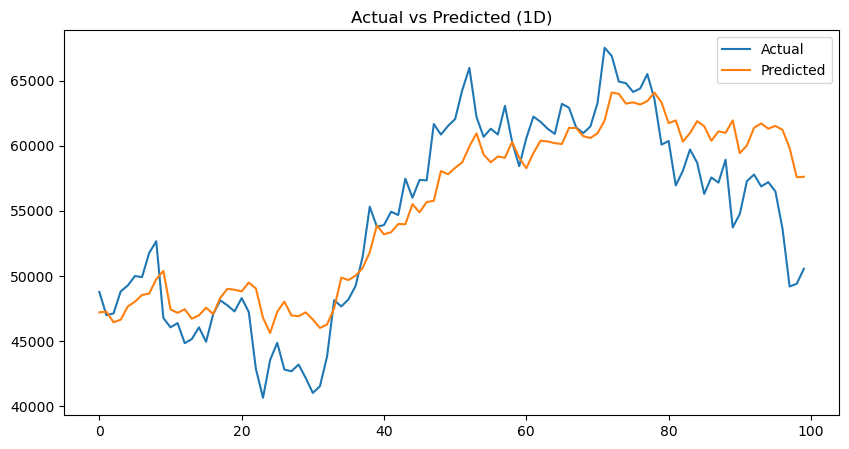

In [39]:
plt.figure(figsize=(10,5))

plt.plot(actual_tf_1d[:100], label="Actual")
plt.plot(pred_tf_1d[:100], label="Predicted")

plt.title("Actual vs Predicted (1D)")
plt.legend()
plt.show()

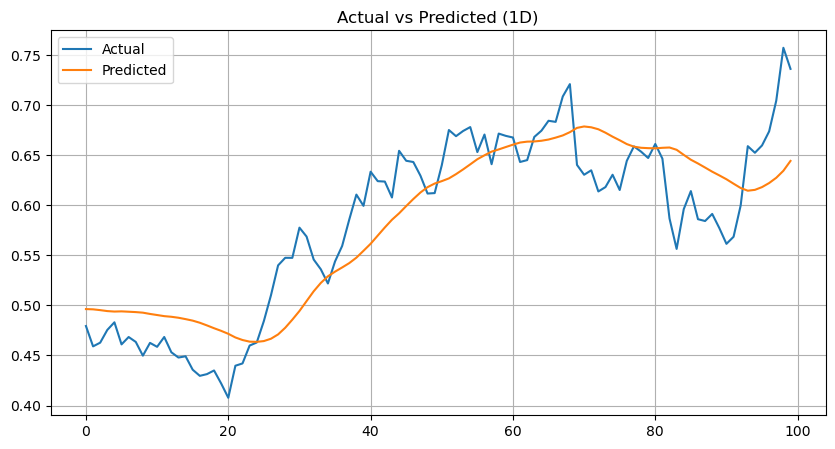

In [35]:
import matplotlib.pyplot as plt

pred = model_lstm_1d(X_te_1d).detach().numpy()
actual = y_te_1d.detach().numpy()

plt.figure(figsize=(10,5))
plt.plot(actual[:100], label="Actual")
plt.plot(pred[:100], label="Predicted")

plt.title("Actual vs Predicted (1D)")
plt.legend()
plt.grid()
plt.show()

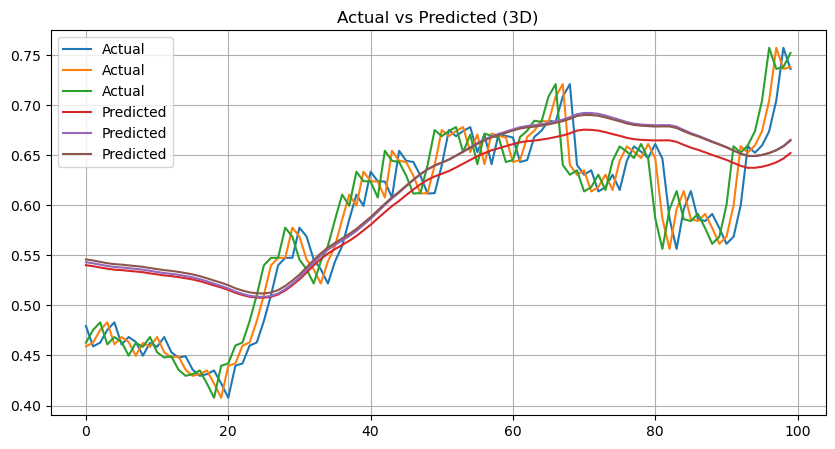

In [36]:
pred = model_lstm_3d(X_te_3d).detach().numpy()
actual = y_te_3d.detach().numpy()

plt.figure(figsize=(10,5))
plt.plot(actual[:100], label="Actual")
plt.plot(pred[:100], label="Predicted")

plt.title("Actual vs Predicted (3D)")
plt.legend()
plt.grid()
plt.show()

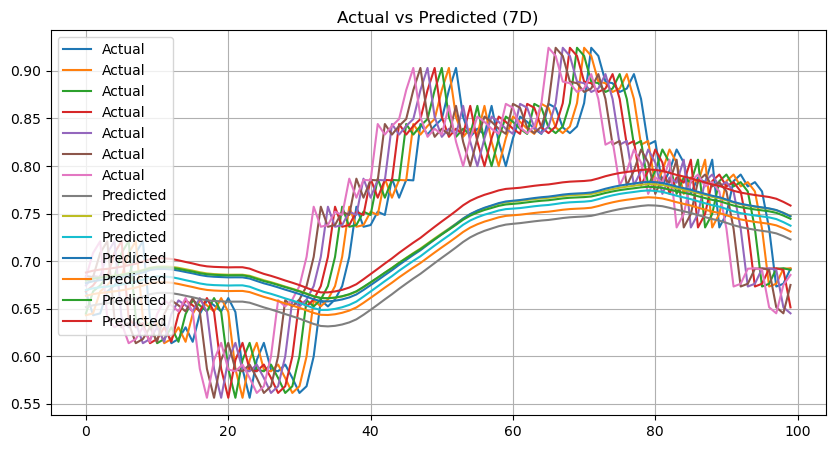

In [43]:
pred = model_lstm_7d(X_te_7d).detach().numpy()
actual = y_te_7d.detach().numpy()

plt.figure(figsize=(10,5))
plt.plot(actual[:100], label="Actual")
plt.plot(pred[:100], label="Predicted")

plt.title("Actual vs Predicted (7D)")
plt.legend()
plt.grid()
plt.show()

In [40]:
import torch
import os

target_dir = '../models'
os.makedirs(target_dir, exist_ok=True)

torch.save(model_lstm_1d.state_dict(), os.path.join(target_dir, 'lstm_1d.pth'))
torch.save(model_lstm_3d.state_dict(), os.path.join(target_dir, 'lstm_3d.pth'))
torch.save(model_lstm_7d.state_dict(), os.path.join(target_dir, 'lstm_7d.pth'))

scaler_params = {
    'min_': scaler.min_,
    'scale_': scaler.scale_,
    'data_min_': scaler.data_min_,
    'data_max_': scaler.data_max_
}
torch.save(scaler_params, os.path.join(target_dir, 'scaler_params.pth'))

df[['Date', 'Price']].to_csv(os.path.join(target_dir, 'processed_bitcoin.csv'), index=False)
